<a href="https://colab.research.google.com/github/SheKJana/first-own-repository/blob/main/DSCI%20HS25/Bildextraktion_alleFr%C3%BCchteBilder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fruits_baum_split **

Es wurden alle vorhanden Bilder verwendet plus in zwei Klassen noch nie gesehene (im Sinn von anderen Lichtbedinungen oder sogar andere Frucht/Gemüse als in Testdaten).

Aktuell Architektur
Titel
feat(model,train,repro): gezielte Augmentation + Cutout, Dropout, Label-Smoothing, class_weight & LR-Schedule; Seeds gesetzt

Body

Reproduzierbarkeit: tf/np/random-Seeds gesetzt → stabile Splits & vergleichbare Runs.

Modell/Augmentation: Rotation/Translation/Zoom/Contrast + RandomErasing(p=0.4) hinzugefügt; Dropout=0.25 vor letztem Dense. Ziel: Sticker+Gelb-Shortcut brechen (Fruchtform priorisieren).

Training: LabelSmoothing=0.05, class_weight (inverse Häufigkeit), ReduceLROnPlateau(f=0.5, patience=8, min_lr=1e-5), EarlyStopping(patience=25). Ziel: stabilere Konvergenz, weniger Überkonfidenz.

Keine Architekturänderung der Conv-Blöcke (64–32–16) – nur Regularisierung & Augs verstärkt.

Evaluation unverändert (Val/Test CM zeilen-normalisiert; PR/ROC der 3 kritischsten Klassen; Wilson-CIs).

Erwarteter Effekt:

Primär: Weniger Frucht-Verwechslungen (insb. banane_extra ↔ citron_*) im Validation-Set; Fokus weg vom Sticker.

Sekundär: Stabilere Val-Kurven, leichte Top-1-Genauigkeits-Verbesserung auf Test oder unverändert bei besserem Recall der kritischen Klassen.

Trade-offs: Etwas längere Trainingszeit; ggf. minimal geringere Trainings-Acc durch Regularisierung.

Kurzüberblick der Ergebnisse (fürs menschliche Auge)

Was wurde geändert?
Mehr realistische Augmentation (Drehen/Verschieben/Zoomen/Kontrast) + Cutout (verdeckt Sticker), dazu Dropout und sanfte Regularisierung im Training (Label-Smoothing, class_weight, LR-Schedule). Die CNN-Struktur blieb gleich.

Warum?
Dein Val-Fehler zeigte: Modell nutzte Sticker + Gelbton als Abkürzung für banane_extra. Wir zwingen es nun, Form/Struktur der Frucht zu lernen.

Worauf achten nach dem Lauf?

Val-Confusion-Matrix: Off-Diagonal citron_* → banane_extra sollte deutlich kleiner sein (idealerweise 0).

Test-Confusion-Matrix: bleibt blockdiagonal → keine neuen Verwechslungen.

Trainingskurven: etwas glatter, val_loss fällt nach LR-Reduktionen weiter.

Fehler-Galerie/Grad-CAM (optional): Heatmaps sollten auf die Frucht, nicht auf den Sticker zielen.

Wenn noch Sticker-Fokus sichtbar ist:
Als nächsten Schritt nur eine Stellschraube drehen: RandomErasing p=0.5 oder image_size 128→160. Danach erneut Val/Test vergleichen.

Hier wurde das Modell (mit der selben Architektur wie bei anderen Trainings) mit den ursprünglichen Trainingsdaten trainiert. Allerdings haben wir bei der Validierung also beim Testing 20 neue banane_extra Bilder verwendet, die zwar ein vergleichbaren Untergrund haben von der Farbe aber andere Textur und Belichtung plus andere Banane.

In [5]:
# ============================================
# BLOCK 1 — Drive mount + Pfade + Imports
# (Quelle: fruits_baum_split/{train,test} + XLSX)
# ============================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import os, random, shutil, json, hashlib
import numpy as np
import pandas as pd

BASE = Path("/content/drive/MyDrive/fruits_baum_split")
TRAIN_DIR = BASE/"train"
TEST_DIR  = BASE/"test"
SPLIT_XLSX = BASE/"train_test_split.xlsx"

assert TRAIN_DIR.exists() and any(TRAIN_DIR.iterdir()), "TRAIN_DIR leer/nicht vorhanden."
assert TEST_DIR.exists()  and any(TEST_DIR.iterdir()),  "TEST_DIR leer/nicht vorhanden."
assert SPLIT_XLSX.exists(), "train_test_split.xlsx nicht gefunden."
print("✅ Struktur gefunden:", BASE)
print("   ↳", TRAIN_DIR)
print("   ↳", TEST_DIR)
print("   ↳", SPLIT_XLSX)


Mounted at /content/drive
✅ Struktur gefunden: /content/drive/MyDrive/fruits_baum_split
   ↳ /content/drive/MyDrive/fruits_baum_split/train
   ↳ /content/drive/MyDrive/fruits_baum_split/test
   ↳ /content/drive/MyDrive/fruits_baum_split/train_test_split.xlsx


In [6]:
# ============================================
# BLOCK 2 — Mapping einlesen (Professor: Dokumentation)
# ============================================

df_split = pd.read_excel(SPLIT_XLSX)
print("🧾 Split-Mapping (Kopf):")
display(df_split.head(8))

print("\nTrain/Test-Verhältnis (aus Mapping):")
display(df_split.groupby(["Klasse","TrainOrTest"]).size().unstack(fill_value=0))


🧾 Split-Mapping (Kopf):


,Dateiname,Pfad,Klasse,TrainOrTest
0,avo_bio_004.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
1,avo_bio_014.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
2,avo_bio_016.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
3,avo_normal_038__test.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
4,avo_normal_039.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
5,avo_normal_040.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
6,avo_normal_041.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
7,avo_normal_042.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test



Train/Test-Verhältnis (aus Mapping):


TrainOrTest,test,train
Klasse,,
avo_bio,3,12
avo_normal,36,39
banane_extra,9,37
banane_normal,2,11
citron_bio,3,12
citron_normal,10,42
mango_extra,5,21
mango_normal,4,16
süssK_bio,3,13


In [7]:
# ============================================
# BLOCK 3 — Klassen-Counts + Duplikat-Check (Name)
# (Professor: saubere Trennung sicherstellen)
# ============================================

def class_counts(root: Path):
    return pd.Series({p.name: len([f for f in p.iterdir() if f.is_file()])
                      for p in sorted(root.iterdir()) if p.is_dir()}).sort_index()

print("📦 Klassenverteilung — TRAIN:")
display(class_counts(TRAIN_DIR))
print("\n📦 Klassenverteilung — TEST:")
display(class_counts(TEST_DIR))

train_names = {f.name for f in TRAIN_DIR.rglob("*/*") if f.is_file()}
test_names  = {f.name for f in TEST_DIR.rglob("*/*") if f.is_file()}
intersect = train_names.intersection(test_names)
print(f"\n🧪 Duplikate (Dateiname) train∩test: {len(intersect)}")
assert len(intersect) == 0, "Dateiname sowohl in train als auch test → bitte Split prüfen."


📦 Klassenverteilung — TRAIN:


,0
avo_bio,12
avo_normal,39
banane_extra,37
banane_normal,11
citron_bio,12
citron_normal,42
mango_extra,21
mango_normal,16
süssK_bio,13
süssK_normal,32



📦 Klassenverteilung — TEST:


,0
avo_bio,3
avo_normal,36
banane_extra,9
banane_normal,2
citron_bio,3
citron_normal,10
mango_extra,5
mango_normal,4
süssK_bio,3
süssK_normal,16



🧪 Duplikate (Dateiname) train∩test: 0


In [8]:
# ============================================
# BLOCK 3b — (Optional) Hash-Check auf echte Inhaltsduplikate
# (Professor macht's nicht explizit; hier ergänzt)
# ============================================

DO_HASH_CHECK = False  # bei Bedarf True setzen (langsamer)

def md5sum(path: Path, chunk=1<<20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while (b := f.read(chunk)):
            h.update(b)
    return h.hexdigest()

if DO_HASH_CHECK:
    def hash_index(root: Path):
        idx = {}
        for f in sorted([p for p in root.rglob("*") if p.is_file()]):
            idx.setdefault(md5sum(f), []).append(f)
        return idx

    train_hash = hash_index(TRAIN_DIR)
    test_hash  = hash_index(TEST_DIR)
    dupe_hashes = set(train_hash).intersection(test_hash)
    print(f"🧪 Duplikate (Inhalt/MD5) train∩test: {len(dupe_hashes)}")
    assert len(dupe_hashes) == 0, "Inhaltsgleiche Dateien in train & test gefunden."


In [9]:
# ============================================
# BLOCK 4 — Datasets laden (Train=80/20 Val, Test separat)
# (Professor-Flow; deine Bildgröße/Batch/Seed)
# ============================================

import tensorflow as tf

image_size = (128, 128)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=seed,
    image_size=image_size, batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=seed,
    image_size=image_size, batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=image_size, batch_size=batch_size
)

class_names = train_ds.class_names
print("🔤 Klassen:", class_names)

# Performance (Cache/Prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(100, seed=seed).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


Found 235 files belonging to 10 classes.
Using 188 files for training.
Found 235 files belonging to 10 classes.
Using 47 files for validation.
Found 91 files belonging to 10 classes.
🔤 Klassen: ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']


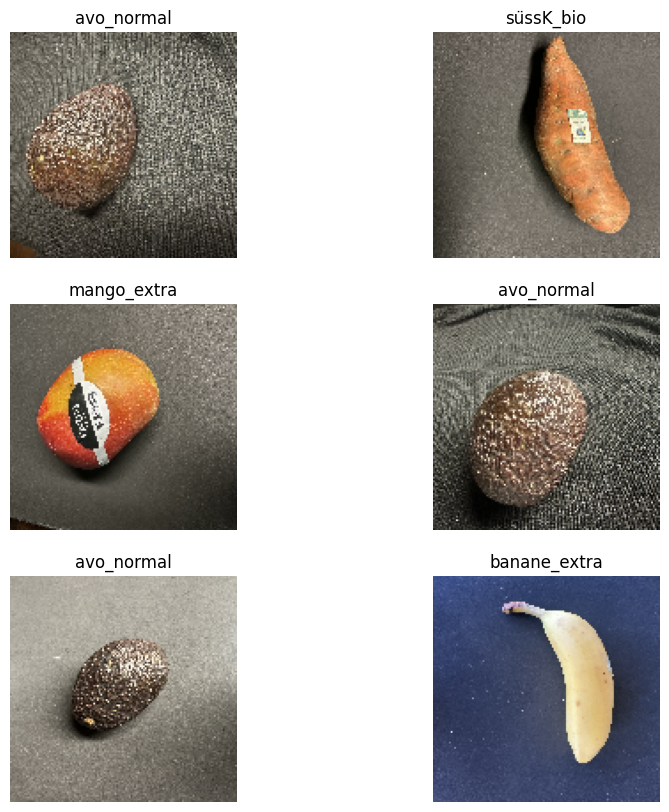

In [10]:
# ============================================
# BLOCK 5 — Sichtprüfung (Sample-Bilder)
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [11]:
# ============================================
# BLOCK 6 — Modell (Logits-Ausgabe, keine Softmax)
# ============================================
from tensorflow.keras import layers

num_classes = len(class_names)
color_image_size = (*image_size, 3)

def make_model():
    img_inputs = tf.keras.Input(shape=color_image_size, name='Eingabe')

    # Preprocessing + (deine) Augmentierungen
    x = layers.Rescaling(1./255)(img_inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)
    # Falls du weitere Augs hast (Translation/Zoom/Contrast/RandomErasing),
    # füge sie hier zusätzlich ein, genau wie bisher.

    # CNN-Backbone (unverändert)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    # WICHTIG: finale Schicht OHNE Aktivierung (Logits)
    logits = layers.Dense(num_classes, activation=None, name='logits')(x)
    return tf.keras.Model(inputs=img_inputs, outputs=logits, name='FruitClassifier')

model = make_model()
model.summary()


Model: "FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Eingabe (InputLayer)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,202 (2.13 MB)

 Trainable params: 558,202 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ============================================
# BLOCK 7 — Kompilieren + Training (from_logits=True)
# ============================================
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"\n📈 Validation Accuracy: {val_acc:.2%}")


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.1297 - loss: 2.2633 - val_accuracy: 0.1489 - val_loss: 2.2875
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2190 - loss: 2.2061 - val_accuracy: 0.1064 - val_loss: 2.2974
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.1523 - loss: 2.1994 - val_accuracy: 0.1064 - val_loss: 2.3087
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2354 - loss: 2.0747 - val_accuracy: 0.2128 - val_loss: 2.2523
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.2231 - loss: 2.0771 - val_accuracy: 0.1277 - val_loss: 2.1287
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3353 - loss: 1.8427 - val_accuracy: 0.2766 - val_loss: 2.1806
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4233 - loss: 1.8347 - val_accuracy: 0.4255 - val_loss: 1.8960
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4963 - loss: 1.5032 - val_accuracy: 0.3830 - val_loss: 1.8510
Epoch

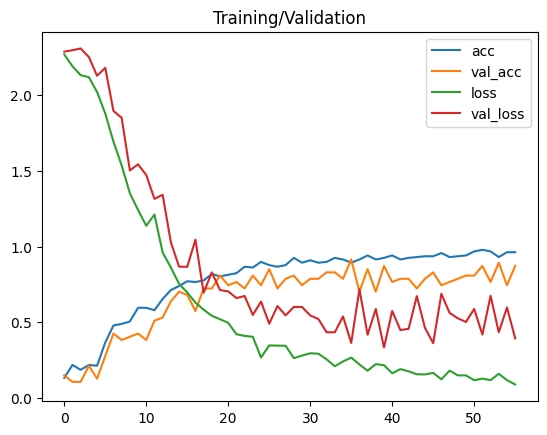

In [13]:
# ============================================
# BLOCK 8 — Trainingskurven
# ============================================

plt.figure()
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training/Validation")
plt.show()


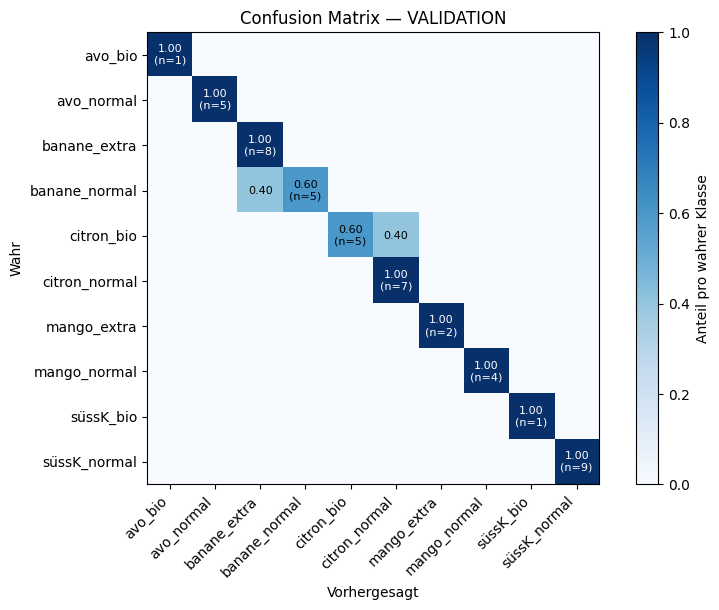


📊 Klassifikationsreport (VALIDATION):
               precision    recall  f1-score   support

      avo_bio       1.00      1.00      1.00         1
   avo_normal       1.00      1.00      1.00         5
 banane_extra       0.80      1.00      0.89         8
banane_normal       1.00      0.60      0.75         5
   citron_bio       1.00      0.60      0.75         5
citron_normal       0.78      1.00      0.88         7
  mango_extra       1.00      1.00      1.00         2
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       1.00      1.00      1.00         1
süssK_normal       1.00      1.00      1.00         9

     accuracy                           0.91        47
    macro avg       0.96      0.92      0.93        47
 weighted avg       0.93      0.91      0.91        47



In [14]:
# ============================================
# BLOCK 9 — Fehleranalyse (VALIDATION)
# Was wird hier gemessen?
# - Datensatz: 20% Validierung aus TRAIN via `validation_split` (subset="validation").
# - Domain: In-domain (gleiche Quelle/Sessions wie Training), NICHT das finale Testset.
# - Aussage: Tuning/Früherkennung von Verwechslungen; tendenziell optimistischer als echter Test.
# ============================================
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Vorhersagen auf Validation sammeln
y_true, y_pred = [], []
for xb, yb in val_ds:
    pr = model.predict(xb, verbose=0)
    y_true.extend(yb.numpy())
    y_pred.extend(np.argmax(pr, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion (zeilen-normalisiert) + Support
cm_val = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
row_sums_v = cm_val.sum(axis=1, keepdims=True).clip(min=1)
cm_val_norm = cm_val / row_sums_v

plt.figure(figsize=(8.5, 6.2))
im = plt.imshow(cm_val_norm, vmin=0, vmax=1, cmap="Blues", aspect='equal')
cb = plt.colorbar(im); cb.set_label("Anteil pro wahrer Klasse", rotation=90)

ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha='right')
plt.yticks(ticks, class_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr")
plt.title("Confusion Matrix — VALIDATION")

# Beschriftung: Diagonale immer inkl. n, Off-Diagonale nur >0; Textfarbe nach Intensität
for i in range(cm_val.shape[0]):
    for j in range(cm_val.shape[1]):
        if i == j:
            val = float(cm_val_norm[i, j])
            txt = f"{val:.2f}\n(n={int(row_sums_v[i,0])})"
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
        else:
            if cm_val[i, j] == 0:
                continue
            val = float(cm_val_norm[i, j])
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

print("\n📊 Klassifikationsreport (VALIDATION):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


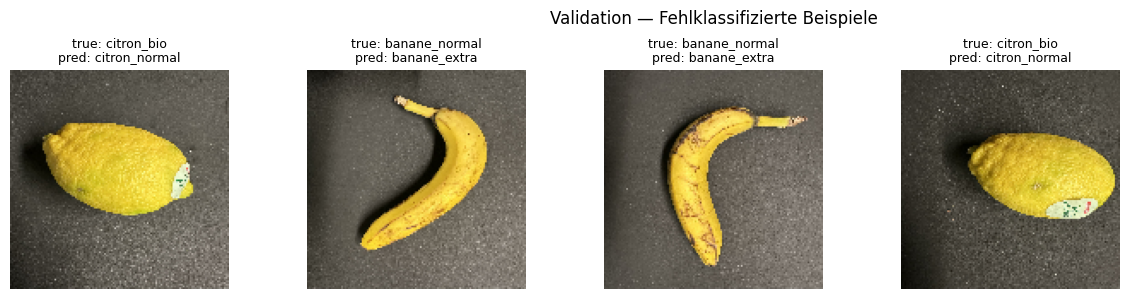

In [15]:
# ============================================
# BLOCK 9b — Fehler-Galerie (VALIDATION): zeige die falsch klassifizierten Val-Bilder
# ============================================
import numpy as np, matplotlib.pyplot as plt

# Vorhersagen + Sammeln der Fehlfälle (wir haben y_true/y_pred aus Block 9)
wrong_imgs, wrong_true, wrong_pred = [], [], []

for xb, yb in val_ds:
    probs = model.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    mism = preds != yb.numpy()
    if np.any(mism):
        wrong_imgs.append(xb.numpy()[mism])
        wrong_true.extend(yb.numpy()[mism])
        wrong_pred.extend(preds[mism])

if wrong_imgs:
    wrong_imgs = np.concatenate(wrong_imgs, axis=0)
    n = len(wrong_imgs)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(wrong_imgs[i].astype("uint8"))
        t = class_names[int(wrong_true[i])]; p = class_names[int(wrong_pred[i])]
        ax.set_title(f"true: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Validation — Fehlklassifizierte Beispiele")
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine Fehlklassifikationen im Validation-Set gefunden.")


In [31]:
# ============================================
# BLOCK 9c — Validation-Logits & Labels sammeln (für Kalibrierung)
# ============================================
val_logits_list, val_labels_list = [], []
for xb, yb in val_ds:
    lg = model.predict(xb, verbose=0)   # logits
    val_logits_list.append(lg)
    val_labels_list.append(yb.numpy())
val_logits = np.concatenate(val_logits_list, axis=0)
val_labels = np.concatenate(val_labels_list, axis=0)

# ============================================
# BLOCK 9d — Temperature Scaling (Kalibrierung) fitten + anwenden
# ============================================
def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def fit_temperature(val_logits, val_labels, iters=300, lr=0.01):
    T = tf.Variable(1.0)
    x = tf.constant(val_logits, dtype=tf.float32)
    y = tf.constant(val_labels, dtype=tf.int32)
    opt = tf.keras.optimizers.Adam(lr)
    for _ in range(iters):
        with tf.GradientTape() as g:
            loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(
                    y, tf.nn.softmax(x / T)
                )
            )
        opt.apply_gradients([(g.gradient(loss, T), T)])
    return float(T.numpy())

T = fit_temperature(val_logits, val_labels)
print(f"🌡️ Temperature (Validation): T = {T:.3f}")

def apply_T(logits, T):
    return softmax_np(logits / T)

val_probs_cal = apply_T(val_logits, T)

# ============================================
# BLOCK 9e — ECE (Calibration-Qualität) berechnen
# ============================================
def ece(probs, labels, n_bins=10):
    confid = probs.max(axis=1)
    preds  = probs.argmax(axis=1)
    accs   = (preds == labels).astype(float)
    bins = np.linspace(0,1,n_bins+1)
    e = 0.0
    for i in range(n_bins):
        m = (confid > bins[i]) & (confid <= bins[i+1])
        if m.any():
            e += abs(confid[m].mean() - accs[m].mean()) * m.mean()
    return e

ece_val = ece(val_probs_cal, val_labels, n_bins=10)
print(f"🎯 ECE (Validation, kalibriert): {ece_val:.4f}")

# ============================================
# BLOCK 9f — Selektive Metriken (Auto vs. Abstain) @ Validation
# Policy: Auto-Entscheid wenn Top-1 ≥ 0.90 und Margin ≥ 0.10
# ============================================
def selective_metrics(probs, labels, conf_thr=0.90, margin_thr=0.10):
    top1 = probs.argmax(axis=1)
    conf1 = probs.max(axis=1)
    # zweitbeste Klasse:
    tmp = probs.copy()
    tmp[np.arange(len(tmp)), top1] = -1
    conf2 = tmp.max(axis=1)
    margin = conf1 - conf2

    auto = (conf1 >= conf_thr) & (margin >= margin_thr)
    coverage = auto.mean()
    sel_top1_recall = (top1[auto] == labels[auto]).mean() if auto.any() else np.nan
    abstain_rate = 1 - coverage
    return sel_top1_recall, coverage, abstain_rate

sel_rec, coverage, a_rate = selective_metrics(val_probs_cal, val_labels, 0.90, 0.10)
print(f"✅ Selektiver Top-1-Recall @Coverage={coverage:.0%}: {sel_rec:.3f} | Abstain: {a_rate:.0%}")

# ============================================
# BLOCK 9g — Frucht-Ebene: robustes Auto-Mapping + Top-2-Recall (Validation)
# ============================================

import numpy as np

def _default_fruit_groups(class_names):
    """
    Erzeuge Gruppen automatisch:
    - Alles vor dem ersten '_' gilt als Fruchtname.
    - Falls kein '_' vorhanden, nimm den kompletten Klassennamen als Frucht.
    """
    groups = {}
    for idx, name in enumerate(class_names):
        key = name.split('_', 1)[0] if '_' in name else name
        groups.setdefault(key, []).append(idx)
    return groups

# Falls fruit_groups noch nicht definiert oder leer ist → Auto-Mapping
_use_auto = False
try:
    fruit_groups
    _valid = isinstance(fruit_groups, dict) and len(fruit_groups) > 0 and any(len(v) > 0 for v in fruit_groups.values())
    if not _valid:
        _use_auto = True
except NameError:
    _use_auto = True

if _use_auto:
    fruit_groups = _default_fruit_groups(class_names)
    print("ℹ️ 'fruit_groups' war leer/ungültig → Auto-Mapping genutzt (Prefix vor '_').")

# Debug-Ausgabe: welche Gruppen haben wir?
print("📦 fruit_groups:")
for k, v in fruit_groups.items():
    print(f"  {k:>12s} -> {[class_names[i] for i in v]}")

# Hilfsfunktionen
def fruit_probs(probs_fine, groups_dict):
    stacks = []
    for idxs in groups_dict.values():
        # Summe der Feinlabel-Wahrscheinlichkeiten innerhalb einer Frucht
        stacks.append(probs_fine[:, idxs].sum(axis=1))
    return np.stack(stacks, axis=1)

def topk_recall_fruit(probs_fruit, true_fruit_idx, k=2):
    # Prüfe, ob die wahre Frucht unter den Top-k liegt (ohne komplettes Sortieren)
    part = np.argpartition(-probs_fruit, kth=k-1, axis=1)[:, :k]
    return np.mean([true_fruit_idx[i] in part[i] for i in range(len(true_fruit_idx))])

# Mapping Feinlabel -> Fruchtindex
fruit_names = list(fruit_groups.keys())
fruit_index_of_fine = np.zeros(len(class_names), dtype=int)
for fi, (_, idxs) in enumerate(fruit_groups.items()):
    for j in idxs:
        fruit_index_of_fine[j] = fi

# Achtung: wir nutzen die KALIBRIERTEN Val-Probs (val_probs_cal) aus 9d
val_probs_fruit = fruit_probs(val_probs_cal, fruit_groups)
val_true_fruit  = np.array([fruit_index_of_fine[i] for i in val_labels])
1
top2_val = topk_recall_fruit(val_probs_fruit, val_true_fruit, k=2)
print(f"🍏 Top-2-Recall (Frucht, Validation): {top2_val:.3f}")

# ============================================
# BLOCK 9h — VALIDATION: Zwei-Stufen-Policy evaluieren & Schwellen vorschlagen
# Voraussetzung: val_probs_cal (kalibriert), val_labels, class_names, fruit_groups (oder Prefix-Auto)
# ============================================
import numpy as np

# 0) Fruit groups robust bereitstellen
def _default_fruit_groups(class_names):
    groups = {}
    for idx, name in enumerate(class_names):
        key = name.split('_', 1)[0] if '_' in name else name
        groups.setdefault(key, []).append(idx)
    return groups

try:
    fruit_groups
    _ok = isinstance(fruit_groups, dict) and len(fruit_groups) > 0 and all(len(v)>0 for v in fruit_groups.values())
    if not _ok: raise NameError
except NameError:
    fruit_groups = _default_fruit_groups(class_names)

fruit_names = list(fruit_groups.keys())

# Mapping Feinlabel -> Fruchtindex
fruit_index_of_fine = np.zeros(len(class_names), dtype=int)
for fi, (_, idxs) in enumerate(fruit_groups.items()):
    for j in idxs: fruit_index_of_fine[j] = fi

def fruit_probs(probs_fine, groups_dict):
    stacks = []
    for idxs in groups_dict.values():
        stacks.append(probs_fine[:, idxs].sum(axis=1))
    return np.stack(stacks, axis=1)

val_probs_fruit = fruit_probs(val_probs_cal, fruit_groups)
val_true_fruit  = np.array([fruit_index_of_fine[i] for i in val_labels])

# 1) Hilfsfunktion: Top-2 effizient (für Fein & Frucht)
def top2_indices(a):
    part = np.argpartition(-a, kth=1, axis=1)
    i1 = part[:,0]; i2 = part[:,1]
    v1 = a[np.arange(len(a)), i1]; v2 = a[np.arange(len(a)), i2]
    swap = v2 > v1
    i1[swap], i2[swap] = i2[swap], i1[swap]
    v1, v2 = np.maximum(v1, v2), np.minimum(v1, v2)
    return i1, v1, i2, v2

i1_fine, c1_fine, i2_fine, c2_fine     = top2_indices(val_probs_cal)
i1_fruit, c1_fruit, i2_fruit, c2_fruit = top2_indices(val_probs_fruit)

same_fruit = (fruit_index_of_fine[i1_fine] == fruit_index_of_fine[i2_fine])

# 2) Sweep über fruit_sum_thr & qual_thr (ohne Ground-Truth in der Policy)
fruit_sum_grid = np.round(np.linspace(0.94, 0.995, 12), 3)  # z.B. 0.94 .. 0.995
qual_thr_grid  = np.round(np.linspace(0.85, 0.95, 11), 2)  # z.B. 0.85 .. 0.95

results = []
for fruit_sum_thr in fruit_sum_grid:
    # Stufe FRUCHT: Auto-Frucht, wenn gleiche Frucht & (Top1_fine + Top2_fine) >= fruit_sum_thr
    # (Summe der beiden besten FEIN-Wahrscheinlichkeiten, die zur gleichen Frucht gehören)
    mask_fruit_auto = same_fruit & ((c1_fine + c2_fine) >= fruit_sum_thr)

    # Fruchtfehler in Auto-Fällen messen (jetzt mit Ground Truth)
    pred_fruit_auto = fruit_index_of_fine[i1_fine[mask_fruit_auto]]
    true_fruit_auto = val_true_fruit[mask_fruit_auto]
    fruit_err = (pred_fruit_auto != true_fruit_auto).mean() if mask_fruit_auto.any() else np.nan

    coverage_fruit = mask_fruit_auto.mean()

    for qual_thr in qual_thr_grid:
        # Stufe QUALITÄT: Unter Auto-Frucht-Fällen volle Auto-Übernahme, wenn Top1_fine >= qual_thr
        mask_full = mask_fruit_auto & (c1_fine >= qual_thr)
        full_rate = mask_full.mean()
        fruit_only_rate = (mask_fruit_auto & ~mask_full).mean()
        manual_rate = 1.0 - (full_rate + fruit_only_rate)

        # Feinlabel-Korrektheit in FULL-Auto-Fällen (nur Info)
        sel_acc_full = (i1_fine[mask_full] == val_labels[mask_full]).mean() if mask_full.any() else np.nan

        results.append({
            "fruit_sum_thr": float(fruit_sum_thr),
            "qual_thr": float(qual_thr),
            "fruit_auto_rate": float(coverage_fruit),
            "fruit_err_rate": float(fruit_err if not np.isnan(fruit_err) else 0.0),
            "full_auto_rate": float(full_rate),
            "fruit_only_rate": float(fruit_only_rate),
            "manual_rate": float(manual_rate),
            "sel_acc_full": float(sel_acc_full if not np.isnan(sel_acc_full) else 0.0),
        })

# 3) Kandidaten filtern: harte Nebenbedingung (Fruchtfehler sehr klein) + Ziel (manuell ≤ 10%)
cands = [r for r in results
         if r["fruit_err_rate"] <= 0.005 and r["manual_rate"] <= 0.10]  # ≤0.5% Fehler, ≤10% manuell

# Sortierung: zuerst höchste Gesamt-Auto-Rate, dann höchste full_auto_rate
cands.sort(key=lambda r: (1.0 - r["manual_rate"], r["full_auto_rate"]), reverse=True)

if cands:
    best = cands[0]
    print("🧭 VAL — empfohlene Schwellen (unter Nebenbedingung Fruchtfehler ≤0.5%, manuell ≤10%):")
    print(f"   fruit_sum_thr = {best['fruit_sum_thr']:.3f}, qual_thr = {best['qual_thr']:.2f}")
    print(f"   Raten: fruit_auto={best['fruit_auto_rate']:.0%} | full_auto={best['full_auto_rate']:.0%} | "
          f"nur_frucht={best['fruit_only_rate']:.0%} | manuell={best['manual_rate']:.0%}")
    print(f"   Auto-Fruchtfehler-Rate: {best['fruit_err_rate']:.3f} | Selektive Fein-Acc (full): {best['sel_acc_full']:.3f}")
else:
    print("ℹ️ VAL — kein Kandidat mit Fruchtfehler ≤0.5% und manuell ≤10%.")
    # Zeige die Top-5 besten Kompromisse (max Auto, min manuell) ohne harte Grenzen
    results.sort(key=lambda r: (1.0 - r['manual_rate'], -r['fruit_err_rate'], r['full_auto_rate']), reverse=True)
    print("   Top-5 Kompromisse (fruit_sum_thr, qual_thr, manuell, Fruchtfehler, full_auto):")
    for r in results[:5]:
        print(f"   ({r['fruit_sum_thr']:.3f}, {r['qual_thr']:.2f})  →  "
              f"manuell={r['manual_rate']:.0%}, Fruchtfehler={r['fruit_err_rate']:.3f}, full_auto={r['full_auto_rate']:.0%}")



🌡️ Temperature (Validation): T = 1.013
🎯 ECE (Validation, kalibriert): 0.1085
✅ Selektiver Top-1-Recall @Coverage=57%: 0.926 | Abstain: 43%
📦 fruit_groups:
           avo -> ['avo_bio', 'avo_normal']
        banane -> ['banane_extra', 'banane_normal']
        citron -> ['citron_bio', 'citron_normal']
         mango -> ['mango_extra', 'mango_normal']
        süssK -> ['süssK_bio', 'süssK_normal']
🍏 Top-2-Recall (Frucht, Validation): 1.000
ℹ️ VAL — kein Kandidat mit Fruchtfehler ≤0.5% und manuell ≤10%.
   Top-5 Kompromisse (fruit_sum_thr, qual_thr, manuell, Fruchtfehler, full_auto):
   (0.940, 0.85)  →  manuell=62%, Fruchtfehler=0.000, full_auto=30%
   (0.945, 0.85)  →  manuell=62%, Fruchtfehler=0.000, full_auto=30%
   (0.940, 0.86)  →  manuell=62%, Fruchtfehler=0.000, full_auto=23%
   (0.940, 0.87)  →  manuell=62%, Fruchtfehler=0.000, full_auto=23%
   (0.940, 0.88)  →  manuell=62%, Fruchtfehler=0.000, full_auto=23%



✅ TEST Accuracy (Keras): 75.82%

📊 Klassifikationsreport (TEST):
               precision    recall  f1-score   support

      avo_bio       0.33      0.67      0.44         3
   avo_normal       0.97      0.83      0.90        36
 banane_extra       0.67      0.89      0.76         9
banane_normal       0.50      0.50      0.50         2
   citron_bio       1.00      0.67      0.80         3
citron_normal       0.91      1.00      0.95        10
  mango_extra       0.31      1.00      0.48         5
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       1.00      1.00      1.00         3
süssK_normal       1.00      0.25      0.40        16

     accuracy                           0.76        91
    macro avg       0.77      0.78      0.72        91
 weighted avg       0.87      0.76      0.76        91



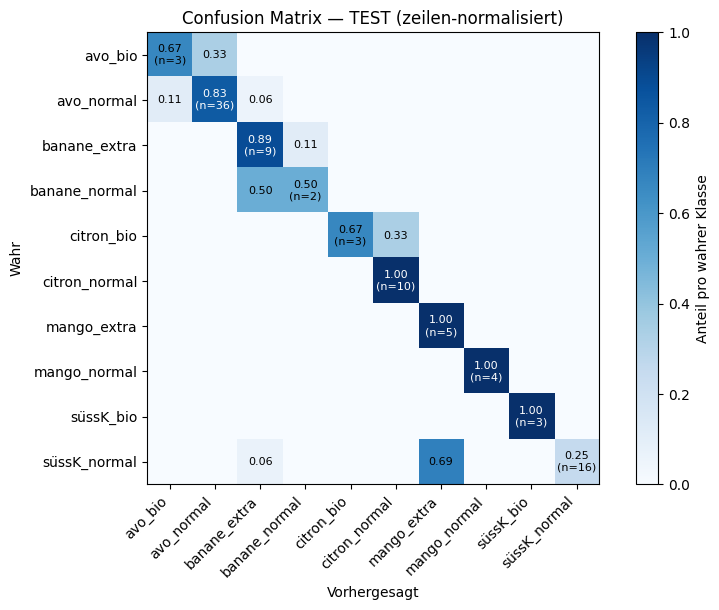

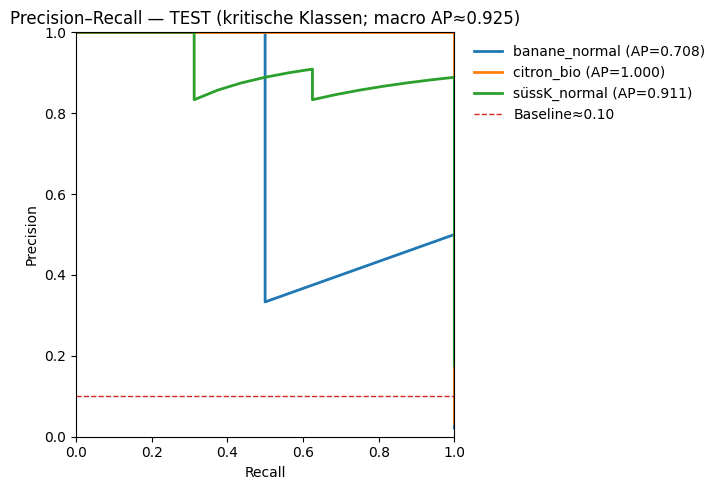

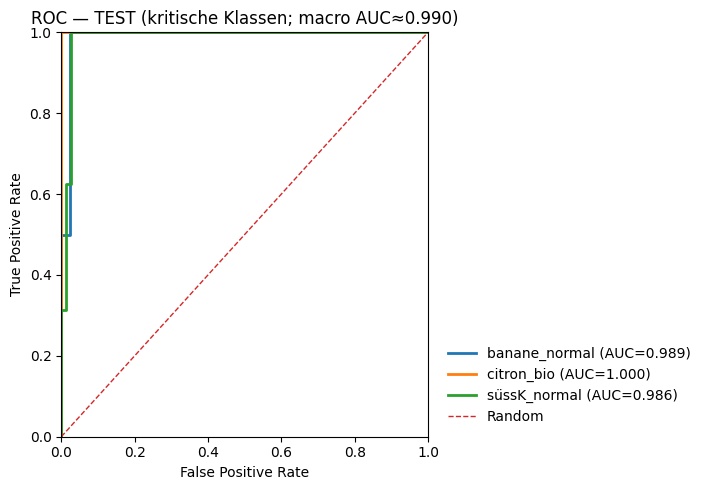

🔒 Gesamt-Accuracy: 69/91 = 75.82%  (Wilson-CI: 66.10% … 83.46%)

📏 Recall + Wilson-CIs pro Klasse:


,klasse,support,recall,recall_CI_low,recall_CI_high
9,süssK_normal,16,0.250000,0.101821,0.494983
3,banane_normal,2,0.500000,0.094531,0.905469
4,citron_bio,3,0.666667,0.207660,0.938508
0,avo_bio,3,0.666667,0.207660,0.938508
1,avo_normal,36,0.833333,0.681092,0.921296
2,banane_extra,9,0.888889,0.565000,0.980109
6,mango_extra,5,1.000000,0.565518,1.000000
5,citron_normal,10,1.000000,0.722467,1.000000
7,mango_normal,4,1.000000,0.510109,1.000000
8,süssK_bio,3,1.000000,0.438503,1.000000


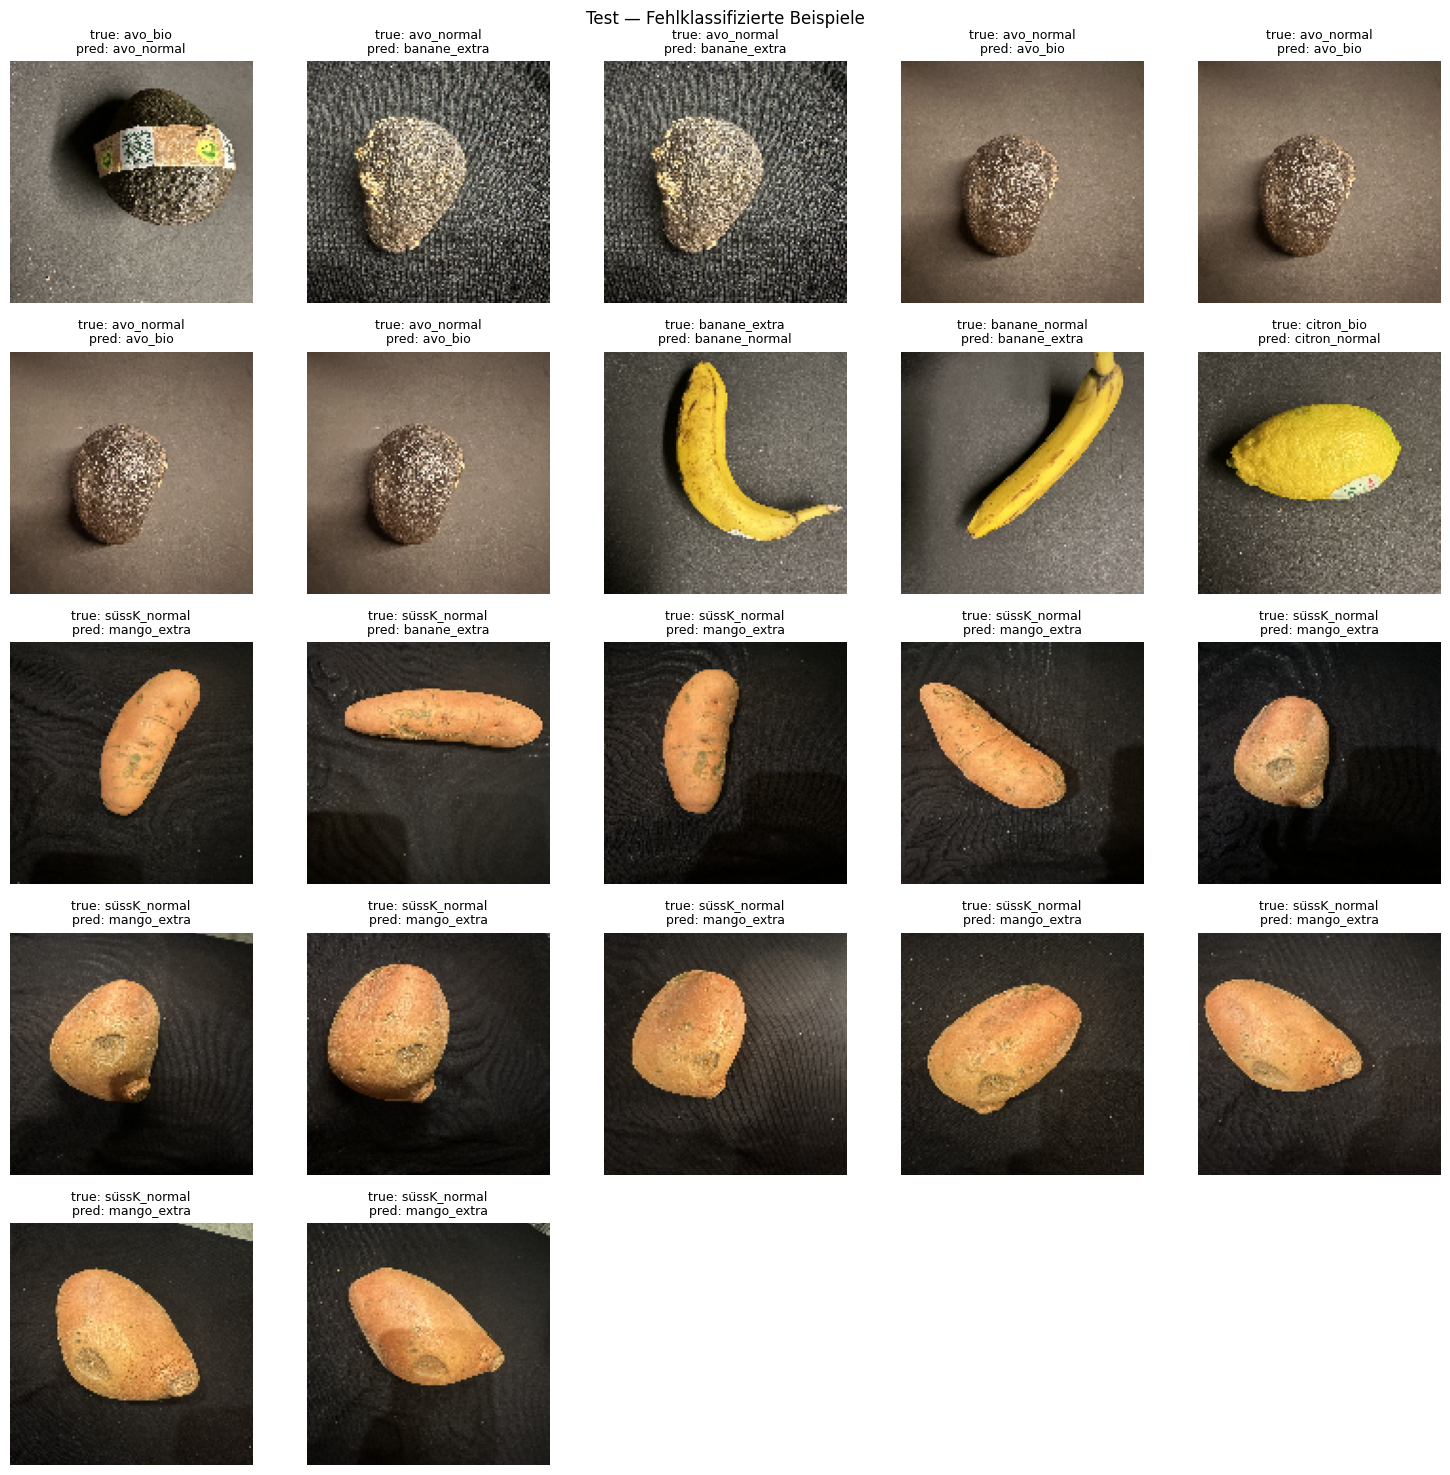

In [19]:
# ============================================
# BLOCK 10 — Finale Test-Evaluation (kalibriert, komplett)
# Enthält:
#  - Keras-Testaccuracy
#  - kalibrierte Wahrscheinlichkeiten (apply_T)
#  - Confusion Matrix (zeilen-normalisiert) inkl. n
#  - Klassifikationsreport
#  - Precision–Recall-Kurven (kritische Klassen + Macro-AP)
#  - ROC-Kurven (kritische Klassen + Macro-AUC)
#  - Wilson-Konfidenzintervalle für Accuracy & Recall je Klasse
#  - Fehler-Galerie (falsch klassifizierte Test-Bilder)
# Voraussetzung:
#  - T aus Validation (BLOCK 9d)
#  - apply_T, fruit_probs, fruit_groups etc. aus BLOCK 9d/9g (falls benötigt)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc
)
from statsmodels.stats.proportion import proportion_confint

# 1) Keras-Testaccuracy (nutzt from_logits intern korrekt)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n✅ TEST Accuracy (Keras): {test_acc:.2%}")

# 2) Logits holen und KALIBRIEREN (mit T aus Validation) → Wahrscheinlichkeiten & harte Predictions
y_true_test   = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_logits_test = model.predict(test_ds, verbose=0)          # logits
y_prob_test   = apply_T(y_logits_test, T)                  # kalibrierte Wahrscheinlichkeiten
y_pred_test   = y_prob_test.argmax(axis=1)                 # harte Vorhersagen

# 3) Klassifikationsreport (auf Basis y_pred_test)
print("\n📊 Klassifikationsreport (TEST):")
print(classification_report(
    [class_names[i] for i in y_true_test],
    [class_names[i] for i in y_pred_test],
    zero_division=0
))

# 4) Confusion Matrix — zeilen-normalisiert (mit n pro Zeile)
num_classes = len(class_names)
cm = confusion_matrix(y_true_test, y_pred_test, labels=np.arange(num_classes))
row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm / row_sums

plt.figure(figsize=(8.5, 6.2))
im = plt.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues", aspect='equal')
cb = plt.colorbar(im); cb.set_label("Anteil pro wahrer Klasse", rotation=90)

ticks = np.arange(num_classes)
plt.xticks(ticks, class_names, rotation=45, ha='right')
plt.yticks(ticks, class_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr")
plt.title("Confusion Matrix — TEST (zeilen-normalisiert)")

for i in range(num_classes):
    for j in range(num_classes):
        if i == j:
            val = float(cm_norm[i, j])
            txt = f"{val:.2f}\n(n={int(row_sums[i,0])})"
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
        else:
            if cm[i, j] == 0:
                continue
            val = float(cm_norm[i, j])
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

# 5) Precision–Recall — zeige die 3 Klassen mit niedrigstem Recall + Macro-AP (über alle Klassen)
y_true_onehot = np.eye(num_classes)[y_true_test]
recall_per_class = (cm.diagonal() / row_sums.squeeze()).astype(float)
worst_idx = np.argsort(recall_per_class)[:3]   # 3 "kritischste" Klassen
keep = set(worst_idx.tolist())

plt.figure(figsize=(7.2, 5.0))
ap_list = []
for i in range(num_classes):
    y_bin = y_true_onehot[:, i]
    p, r, _ = precision_recall_curve(y_bin, y_prob_test[:, i])  # kalibrierte Probs!
    ap = auc(r, p) if len(r) > 1 else 0.0
    ap_list.append(ap)
    if i in keep:
        plt.plot(r, p, lw=2, label=f"{class_names[i]} (AP={ap:.3f})")

macro_ap = float(np.mean(ap_list)) if ap_list else 0.0
baseline = float(y_true_onehot.mean(axis=0).mean())
plt.plot([0,1],[baseline,baseline], '--', lw=1, label=f"Baseline≈{baseline:.2f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision–Recall — TEST (kritische Klassen; macro AP≈{macro_ap:.3f})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()

# 6) ROC — zeige die 3 Klassen mit niedrigstem Recall + Macro-AUC (über alle Klassen)
plt.figure(figsize=(7.2, 5.0))
auc_list = []
for i in range(num_classes):
    y_bin = y_true_onehot[:, i]
    fpr, tpr, _ = roc_curve(y_bin, y_prob_test[:, i])           # kalibrierte Probs!
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)
    if i in keep:
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], '--', lw=1, label="Random")
macro_auc = float(np.mean(auc_list)) if auc_list else 0.0
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC — TEST (kritische Klassen; macro AUC≈{macro_auc:.3f})")
plt.legend(bbox_to_anchor=(1.02, 0), loc="lower left", frameon=False)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()

# 7) Wilson-Konfidenzintervalle — Gesamt-Accuracy & Recall je Klasse
hits_total = int((y_true_test == y_pred_test).sum())
n_total    = int(len(y_true_test))
lo, hi = proportion_confint(hits_total, n_total, method='wilson')
print(f"🔒 Gesamt-Accuracy: {hits_total}/{n_total} = {hits_total/n_total:.2%}  (Wilson-CI: {lo:.2%} … {hi:.2%})")

recall_hits = cm.diagonal().astype(int)
supports    = cm.sum(axis=1).astype(int)
rows = []
for i, c in enumerate(class_names):
    if supports[i] > 0:
        r_lo, r_hi = proportion_confint(recall_hits[i], supports[i], method='wilson')
        rows.append({
            "klasse": c,
            "support": int(supports[i]),
            "recall": float(recall_hits[i]/supports[i]),
            "recall_CI_low": float(r_lo),
            "recall_CI_high": float(r_hi)
        })

# Optional: als kleine Tabelle ausgeben
try:
    import pandas as pd
    df_ci = pd.DataFrame(rows).sort_values("recall")
    print("\n📏 Recall + Wilson-CIs pro Klasse:")
    display(df_ci)
except Exception:
    print("\n📏 Recall + Wilson-CIs pro Klasse (roh):")
    for r in rows:
        print(r)

# 8) Fehler-Galerie — falsch klassifizierte Test-Bilder
wrong_imgs_t, wrong_true_t, wrong_pred_t = [], [], []

# Hinweis: wir müssen die Original-Bilder erneut iterieren, um die Pixel zu zeigen
for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    probs = apply_T(probs, T)                              # kalibriert
    preds = probs.argmax(axis=1)
    mism = preds != yb.numpy()
    if np.any(mism):
        wrong_imgs_t.append(xb.numpy()[mism])
        wrong_true_t.extend(yb.numpy()[mism])
        wrong_pred_t.extend(preds[mism])

if wrong_imgs_t:
    wrong_imgs_t = np.concatenate(wrong_imgs_t, axis=0)
    n = len(wrong_imgs_t)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(wrong_imgs_t[i].astype("uint8"))
        t = class_names[int(wrong_true_t[i])]; p = class_names[int(wrong_pred_t[i])]
        ax.set_title(f"true: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Test — Fehlklassifizierte Beispiele")
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine Fehlklassifikationen im Test-Set gefunden.")


In [28]:
# ============================================
# BLOCK 10s — Test: ECE, selektive Metriken, Frucht-Top-2 (robust & kalibriert)
# Voraussetzung: BLOCK 10 lief und hat y_logits_test, y_true_test erzeugt.
# ============================================
import numpy as np

# 0) Kalibrierte Test-Wahrscheinlichkeiten sicherstellen
#    (nutzt apply_calibrated aus 9d_alt, oder apply_T(T) aus 9d)
try:
    y_prob_test
except NameError:
    try:
        y_prob_test = apply_calibrated(y_logits_test)
    except NameError:
        y_prob_test = apply_T(y_logits_test, T)

# 1) ECE & selektive Metriken (Conf+Margin) — identisch zu Validation
def ece(probs, labels, n_bins=10):
    confid = probs.max(axis=1)
    preds  = probs.argmax(axis=1)
    accs   = (preds == labels).astype(float)
    bins = np.linspace(0,1,n_bins+1)
    e = 0.0
    for i in range(n_bins):
        m = (confid > bins[i]) & (confid <= bins[i+1])
        if m.any():
            e += abs(confid[m].mean() - accs[m].mean()) * m.mean()
    return e

def selective_metrics(probs, labels, conf_thr=0.90, margin_thr=0.10):
    part   = np.partition(-probs, kth=1, axis=1)
    conf1  = -part[:, 0]
    conf2  = -part[:, 1]
    top1   = probs.argmax(axis=1)
    margin = conf1 - conf2
    auto   = (conf1 >= conf_thr) & (margin >= margin_thr)
    coverage = auto.mean()
    sel_top1_recall = (top1[auto] == labels[auto]).mean() if auto.any() else np.nan
    abstain_rate = 1 - coverage
    return sel_top1_recall, coverage, abstain_rate

ece_test = ece(y_prob_test, y_true_test, n_bins=10)
sel_rec_t, coverage_t, a_rate_t = selective_metrics(y_prob_test, y_true_test, 0.90, 0.10)
print(f"🎯 ECE (TEST, kalibriert): {ece_test:.4f}")
print(f"✅ TEST — Selektiver Top-1-Recall @Coverage={coverage_t:.0%}: "
      f"{'nan' if np.isnan(sel_rec_t) else f'{sel_rec_t:.3f}'} | Abstain: {a_rate_t:.0%}")

# 2) Frucht-Gruppen (robust): Auto-Mapping per Prefix '_' falls nichts gesetzt
def _default_fruit_groups(class_names):
    groups = {}
    for idx, name in enumerate(class_names):
        key = name.split('_', 1)[0] if '_' in name else name
        groups.setdefault(key, []).append(idx)
    return groups

try:
    fruit_groups
    _ok = isinstance(fruit_groups, dict) and len(fruit_groups) > 0 and all(len(v)>0 for v in fruit_groups.values())
    if not _ok: raise NameError
except NameError:
    fruit_groups = _default_fruit_groups(class_names)
    print("ℹ️ 'fruit_groups' war leer/ungültig → Auto-Mapping (Prefix) verwendet.")

# 3) Frucht-Top-2 Recall
fruit_names = list(fruit_groups.keys())
fruit_index_of_fine = np.zeros(len(class_names), dtype=int)
for fi, (_, idxs) in enumerate(fruit_groups.items()):
    for j in idxs:
        fruit_index_of_fine[j] = fi

def fruit_probs(probs_fine, groups_dict):
    stacks = []
    for idxs in groups_dict.values():
        stacks.append(probs_fine[:, idxs].sum(axis=1))
    return np.stack(stacks, axis=1)

def topk_recall_fruit(probs_fruit, true_fruit_idx, k=2):
    part = np.argpartition(-probs_fruit, kth=k-1, axis=1)[:, :k]
    return np.mean([true_fruit_idx[i] in part[i] for i in range(len(true_fruit_idx))])

test_probs_fruit = fruit_probs(y_prob_test, fruit_groups)
test_true_fruit  = np.array([fruit_index_of_fine[i] for i in y_true_test])
top2_test = topk_recall_fruit(test_probs_fruit, test_true_fruit, k=2)
print(f"🍏 Top-2-Recall (Frucht, TEST): {top2_test:.3f}")

# 4) Optional: Mapping einmal ausgeben (hilft für die Doku)
print("📦 fruit_groups (TEST):")
for k, v in fruit_groups.items():
    print(f"  {k:>12s} -> {[class_names[i] for i in v]}")


🎯 ECE (TEST, kalibriert): 0.1341
✅ TEST — Selektiver Top-1-Recall @Coverage=60%: 0.909 | Abstain: 40%
🍏 Top-2-Recall (Frucht, TEST): 0.989
📦 fruit_groups (TEST):
           avo -> ['avo_bio', 'avo_normal']
        banane -> ['banane_extra', 'banane_normal']
        citron -> ['citron_bio', 'citron_normal']
         mango -> ['mango_extra', 'mango_normal']
        süssK -> ['süssK_bio', 'süssK_normal']


In [30]:
# ============================================
# BLOCK 10u — Policy: Stufe 1 (Frucht sicher) → Stufe 2 (Qualität sicher)
#  - Auto (fein): conf1_fine ≥ conf_thr & margin ≥ margin_thr
#  - Auto (frucht,sum): same fruit & (p1_fine + p2_fine) ≥ samefruit_sum_thr
#    → innerhalb dessen: wenn conf1_fine ≥ qual_thr → vollauto (Frucht+Qualität),
#                        sonst: auto nur Frucht (Qualität konservativ/min)
#  - sonst: "manual"
# ============================================
import numpy as np

# kalibrierte Probabilities aus Test
try:
    probs_test = apply_calibrated(y_logits_test)
except NameError:
    probs_test = apply_T(y_logits_test, T)

# Frucht-Gruppen (Prefix-Automapping falls nicht gesetzt)
def _default_fruit_groups(class_names):
    groups = {}
    for idx, name in enumerate(class_names):
        key = name.split('_', 1)[0] if '_' in name else name
        groups.setdefault(key, []).append(idx)
    return groups

try:
    fruit_groups
    _ok = isinstance(fruit_groups, dict) and len(fruit_groups) > 0
    if not _ok: raise NameError
except NameError:
    fruit_groups = _default_fruit_groups(class_names)

fruit_names = list(fruit_groups.keys())
fruit_index_of_fine = np.zeros(len(class_names), dtype=int)
for fi, (_, idxs) in enumerate(fruit_groups.items()):
    for j in idxs:
        fruit_index_of_fine[j] = fi

def fruit_probs(probs_fine, groups_dict):
    return np.stack([probs_fine[:, idxs].sum(axis=1) for idxs in groups_dict.values()], axis=1)

probs_fruit_test = fruit_probs(probs_test, fruit_groups)
true_fruit_test  = np.array([fruit_index_of_fine[i] for i in y_true_test])

# Schwellen — final aus Validation übernehmen!
conf_thr          = 0.90   # Auto (fein) Confidence
margin_thr        = 0.10   # Auto (fein) Margin
samefruit_sum_thr = 0.98   # Auto (frucht,sum) Summe p1+p2
qual_thr          = 0.90   # Stufe-2: Qualität sicher

def top2_indices(a):
    part = np.argpartition(-a, kth=1, axis=1)
    i1 = part[:,0]; i2 = part[:,1]
    v1 = a[np.arange(len(a)), i1]; v2 = a[np.arange(len(a)), i2]
    swap = v2 > v1
    i1[swap], i2[swap] = i2[swap], i1[swap]
    v1, v2 = np.maximum(v1, v2), np.minimum(v1, v2)
    return i1, v1, i2, v2

i1_fine, c1_fine, i2_fine, c2_fine     = top2_indices(probs_test)
i1_fruit, c1_fruit, i2_fruit, c2_fruit = top2_indices(probs_fruit_test)

n = len(y_true_test)
decision = np.array(["manual"]*n, dtype=object)  # 'auto_fine' | 'auto_full' | 'auto_fruit_only' | 'manual'
pred_fine = np.full(n, -1, dtype=int)
pred_fruit= np.full(n, -1, dtype=int)

# A) Auto (fein): sehr sicher
mask_auto_fine = (c1_fine >= conf_thr) & ((c1_fine - c2_fine) >= margin_thr)
decision[mask_auto_fine] = "auto_full"
pred_fine[mask_auto_fine] = i1_fine[mask_auto_fine]
pred_fruit[mask_auto_fine]= fruit_index_of_fine[i1_fine[mask_auto_fine]]

# B) Auto (frucht,sum): gleiche Frucht + hohe Summe
same_fruit = fruit_index_of_fine[i1_fine] == fruit_index_of_fine[i2_fine]
sum_ok     = (c1_fine + c2_fine) >= samefruit_sum_thr
mask_fruit = (~mask_auto_fine) & same_fruit & sum_ok

#   B1) Qualität zusätzlich sicher → vollauto
mask_full = mask_fruit & (c1_fine >= qual_thr)
decision[mask_full]   = "auto_full"
pred_fine[mask_full]  = i1_fine[mask_full]
pred_fruit[mask_full] = fruit_index_of_fine[i1_fine[mask_full]]

#   B2) Qualität nicht sicher → nur Frucht auto, Qualität konservativ (min)
mask_fruit_only = mask_fruit & (c1_fine < qual_thr)
decision[mask_fruit_only]   = "auto_fruit_only"
# wähle konservativ die günstigere Qualitätsklasse innerhalb dieser Frucht:
for idx in np.where(mask_fruit_only)[0]:
    fr = fruit_index_of_fine[i1_fine[idx]]
    # nimm die "billigste" Klasse dieser Frucht (einfach: niedrigster Index in Gruppe)
    pred_fine[idx]  = min(fruit_groups[fruit_names[fr]])
    pred_fruit[idx] = fr

# C) Rest → manuelle Eingabe
manual_rate = (decision == "manual").mean()

# Kennzahlen
auto_full_rate  = (decision == "auto_full").mean()
auto_fruit_rate = (decision == "auto_fruit_only").mean()
auto_rate       = 1 - manual_rate

print("🧭 Policy (TEST) — 2-Stufen-Regel:")
print(f"   Auto (voll: Frucht+Qualität) : {auto_full_rate:.0%}")
print(f"   Auto (nur Frucht, konservativ): {auto_fruit_rate:.0%}")
print(f"   Manuelle Eingabe              : {manual_rate:.0%}")
print(f"   Gesamt Auto-Rate              : {auto_rate:.0%}")

# Qualitätsmetriken
auto_any = (decision != "manual")
sel_acc_full = (pred_fine[auto_any] == y_true_test[auto_any]).mean() if auto_any.any() else float('nan')
print(f"   Selektive Top-1-Accuracy (alle Auto-Fälle): {sel_acc_full:.3f}")

# Frucht-Fehlerrate der Auto-Fälle (soll sehr niedrig sein)
true_fruit_auto = np.array([fruit_index_of_fine[i] for i in y_true_test[auto_any]])
pred_fruit_auto = pred_fruit[auto_any]
fruit_err = (pred_fruit_auto != true_fruit_auto).mean() if auto_any.any() else float('nan')
print(f"   Auto-Fruchtfehler-Rate: {fruit_err:.3f}")


🧭 Policy (TEST) — 2-Stufen-Regel:
   Auto (voll: Frucht+Qualität) : 60%
   Auto (nur Frucht, konservativ): 10%
   Manuelle Eingabe              : 30%
   Gesamt Auto-Rate              : 70%
   Selektive Top-1-Accuracy (alle Auto-Fälle): 0.828
   Auto-Fruchtfehler-Rate: 0.000


In [20]:
# ============================================
# BLOCK 11 — Modell + Label-Mapping speichern (Drive)
# (Professor speichert Modell; hier zusätzlich Klassen-JSON)
# ============================================

MODEL_DIR = BASE/"model_out"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

keras_path = MODEL_DIR/"model_fruits.keras"
model.save(keras_path)
print("💾 Modell gespeichert:", keras_path)

labels_path = MODEL_DIR/"class_names.json"
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump({"class_names": class_names}, f, ensure_ascii=False, indent=2)
print("💾 Klassen gespeichert:", labels_path)

# Reload-Test
_ = tf.keras.models.load_model(keras_path)
print("🔁 Reload OK.")


💾 Modell gespeichert: /content/drive/MyDrive/fruits_baum_split/model_out/model_fruits.keras
💾 Klassen gespeichert: /content/drive/MyDrive/fruits_baum_split/model_out/class_names.json
🔁 Reload OK.


In [24]:
# ============================================
# BLOCK 12 — OOD/Session-Shift Test (kalibriert, optional)
# ============================================
RUN_OOD = False
OOD_DIR = Path("/content/drive/MyDrive/banane_extra")  # Beispielpfad

if RUN_OOD:
    assert OOD_DIR.exists(), "OOD-Ordner nicht gefunden."
    img_exts = {".jpg",".jpeg",".png"}
    files = sorted([p for p in OOD_DIR.iterdir() if p.is_file() and p.suffix.lower() in img_exts])
    if not files:
        raise RuntimeError("Keine OOD-Bilder gefunden.")

    def load_and_preprocess(path):
        img_b = tf.io.read_file(path)
        img = tf.image.decode_image(img_b, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        return tf.cast(img, tf.float32)

    paths = [str(p) for p in files]
    ood_ds = tf.data.Dataset.from_tensor_slices(paths).map(load_and_preprocess).batch(batch_size)
    logits = model.predict(ood_ds, verbose=0)
    probs  = apply_T(logits, T)                         # ← kalibriert
    preds  = probs.argmax(axis=1)

    target = "banane_extra"
    if target in class_names:
        tidx = class_names.index(target)
        hits = int(np.sum(preds == tidx))
        n = len(preds)
        print(f"🍌 OOD '{target}': {hits}/{n} ({hits/n:.1%})")
    else:
        print("⚠️ Zielklasse für OOD nicht in class_names:", class_names)
